In [77]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml('mnist_784', version=1,
                    return_X_y=True)
X = X.values
y = y.astype(int).values


In [78]:
print(X.shape, y.shape)

(70000, 784) (70000,)


In [79]:
X = ((X / 255.) - .5) * 2
X[y == 0][0]

array([-1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.  

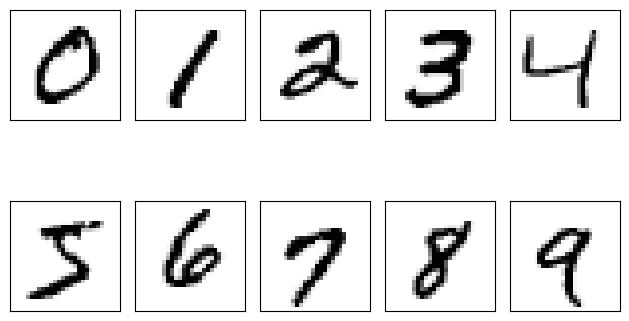

In [80]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=2, ncols=5,
                       sharex=True, sharey=True)
ax = ax.flatten()
for i in range(10):
    img = X[y == i][0].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys')
ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

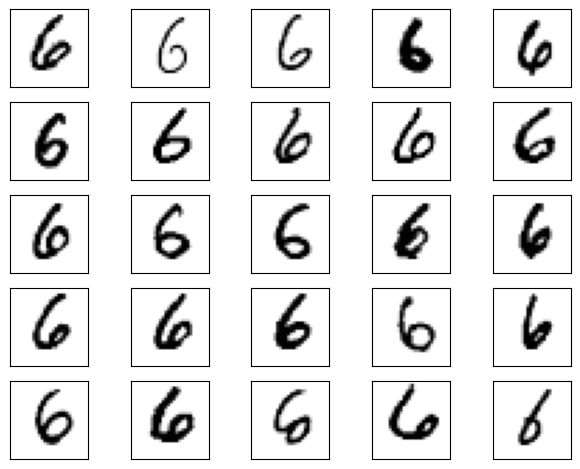

In [81]:
fig, ax = plt.subplots(nrows=5, ncols=5,
                       sharex=True, sharey=True)
ax = ax.flatten()
for i in range(25):
    img = X[y == 6][i].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys')
ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

In [82]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=5000, random_state=123, stratify=y)
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=5000, random_state=123, stratify=y_temp)

In [83]:
import numpy as np


def sigmoid(z):
    return 1. / (1. + np.exp(-z))


def int_to_onehot(y, num_labels):
    ary = np.zeros((y.shape[0], num_labels))
    for i, val in enumerate(y):
        ary[i, val] = 1
    return ary


class NeuralNetMLP:

    def __init__(self, num_features, num_hidden, num_classes, random_seed=123):
        super().__init__()
        self.num_classes = num_classes

        rng = np.random.RandomState(random_seed)

        # Скрытый слой
        self.weight_h = rng.normal(loc=0., scale=0.1, size=(num_hidden, num_features))
        self.bias_h = np.zeros(num_hidden)

        # Выход
        self.weight_out = rng.normal(loc=0., scale=0.1, size=(num_classes, num_hidden))
        self.bias_out = np.zeros(num_classes)

    def forward(self, x):
        # Скрытый слой
        # размерность входа: [n_examples, n_features]
        #                 dot [n_hidden, n_features].T
        # размерность выхода: [n_examples, n_hidden]
        z_h = np.dot(x, self.weight_h.T) + self.bias_h
        a_h = sigmoid(z_h)
        # Выходной слой
        # размерность входа: [n_examples, n_hidden]
        #                 dot [n_classes, n_hidden].T
        # размерность выхода: [n_examples, n_classes]
        z_out = np.dot(a_h, self.weight_out.T) + self.bias_out
        a_out = sigmoid(z_out)
        return a_h, a_out

    def backward(self, x, a_h, a_out, y):
        #########################
        ### Веса выходного слоя
        #########################

        # унитарное кодирование
        y_onehot = int_to_onehot(y, self.num_classes)

        # Часть 1: dLoss/dOutWeights
        ## = dLoss/dOutAct * dOutAct/dOutNet * dOutNet/DOutWeight
        ## where DeltaOut = dLoss/dOutAct * dOutAct/dOutNet
        ## для удобства повторного использования

        # размер входа/выхода : [n_examples, n_classes]
        d_loss__d_a_out = 2. * (a_out - y_onehot) / y.shape[0]

        # размер входа/выхода : [n_examples, n_classes]
        d_a_out__d_z_out = a_out * (1. - a_out)  # сигмоидная производная

        # размер выхода: [n_examples, n_classes]
        delta_out = d_loss__d_a_out * d_a_out__d_z_out

        # градиент для выходных весов

        # [n_examples, n_hidden]
        d_z_out__dw_out = a_h

        # размер входа: [n_classes, n_examples] dot [n_examples, n_hidden]
        # размер выхода: [n_classes, n_hidden]
        d_loss__dw_out = np.dot(delta_out.T, d_z_out__dw_out)
        d_loss__db_out = np.sum(delta_out, axis=0)

        #################################
        # Часть 2: dLoss/dHiddenWeights
        ## = DeltaOut * dOutNet/dHiddenAct * dHiddenAct/dHiddenNet * dHiddenNet/dWeight

        # [n_classes, n_hidden]
        d_z_out__a_h = self.weight_out

        # размер выхода: [n_examples, n_hidden]
        d_loss_a_h = np.dot(delta_out, d_z_out__a_h)

        # [n_examples, n_hidden]
        d_a_h__d_z_h = a_h * (1. - a_h)  # сигмоидная производная

        # [n_examples, n_features]
        d_z_h__d_w_h = x

        # размер выхода: [n_hidden, n_features]
        d_loss__d_w_h = np.dot((d_loss_a_h * d_a_h__d_z_h).T, d_z_h__d_w_h)
        d_loss__d_b_h = np.sum((d_loss_a_h * d_a_h__d_z_h), axis=0)

        return (d_loss__dw_out, d_loss__db_out,
                d_loss__d_w_h, d_loss__d_b_h)

In [84]:
model = NeuralNetMLP(num_features=28 * 28, num_hidden=50, num_classes=10)

In [85]:
import numpy as np

num_epochs = 50
minibatch_size = 100


def minibatch_generator(X, y, minibatch_size):
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)
    for start_idx in range(0, indices.shape[0] - minibatch_size + 1, minibatch_size):
        batch_idx = indices[start_idx:start_idx + minibatch_size]
        yield X[batch_idx], y[batch_idx]

In [86]:
for i in range(num_epochs):
    minibatch_gen = minibatch_generator(X_train, y_train, minibatch_size)
    for X_train_mini, y_train_mini in minibatch_gen:
        break
    break
print(X_train_mini.shape)
print(y_train_mini.shape)

(100, 784)
(100,)


In [87]:
def mse_loss(targets, probas, num_labels=10):
    onehot_targets = int_to_onehot(targets, num_labels)
    return np.mean((onehot_targets - probas) ** 2)


def accuracy(targets, predicted_labels):
    return np.mean(predicted_labels == targets)

In [88]:
_, probas = model.forward(X_valid)
mse = mse_loss(y_valid, probas)
print(f'Начальная MSE при валидации: {mse:.1f}')

Начальная MSE при валидации: 0.3


In [89]:
predicted_labels = np.argmax(probas, axis=1)
acc = accuracy(y_valid, predicted_labels)
print(f'Начальная точность при валидации: {acc * 100:.1f}%')

Начальная точность при валидации: 9.4%


In [90]:
def compute_mse_and_acc(nnet, X, y, num_labels=10, minibatch_size=100):
    mse, correct_pred, num_examples = 0., 0, 0
    minibatch_gen = minibatch_generator(X, y, minibatch_size)
    for i, (features, targets) in enumerate(minibatch_gen):
        _, probas = nnet.forward(features)
        predicted_labels = np.argmax(probas, axis=1)
        onehot_targets = int_to_onehot(targets, num_labels)
        loss = np.mean((onehot_targets - probas) ** 2)
        correct_pred += (predicted_labels == targets).sum()
        num_examples += targets.shape[0]
        mse += loss
    mse = mse/i
    acc = correct_pred / num_examples
    return mse, acc

In [91]:
mse, acc = compute_mse_and_acc(model, X_valid, y_valid)
print(f'Начальная MSE при валидации: {mse:.1f}')
print(f'Начальная точность при валидации: {acc * 100:.1f}%')

Начальная MSE при валидации: 0.3
Начальная точность при валидации: 9.4%


In [92]:
def train(model, X_train, y_train, X_valid, y_valid, num_epochs, learning_rate=0.1):
    epoch_loss = []
    epoch_train_acc = []
    epoch_valid_acc = []

    for e in range(num_epochs):
        minibatch_gen = minibatch_generator(X_train, y_train, minibatch_size)
        for X_train_mini, y_train_mini in minibatch_gen:
            a_h, a_out = model.forward(X_train_mini)

            d_loss__d_w_out , d_loss__d_b_out, \
            d_loss__d_w_h, d_loss__d_b_h = \
            model.backward(X_train_mini, a_h, a_out, y_train_mini)

            model.weight_h -= learning_rate * d_loss__d_w_h
            model.bias_h -= learning_rate * d_loss__d_b_h
            model.weight_out -= learning_rate * d_loss__d_w_out
            model.bias_out -= learning_rate * d_loss__d_b_out
        train_mse, train_acc = compute_mse_and_acc(model, X_train, y_train)
        valid_mse, valid_acc = compute_mse_and_acc(model, X_valid, y_valid)
        train_acc, valid_acc = train_acc * 100, valid_acc * 100
        epoch_train_acc.append(train_acc)
        epoch_valid_acc.append(valid_acc)
        epoch_loss.append(train_mse)
        print(f'Эпоха: {e+1:03d}/{num_epochs:03d}'
              f'| Train MSE: {train_mse:.2f}'
              f'| Train Acc: {train_acc:.2f}%'
              f'| Valid Acc: {valid_acc:.2f}%')
    return epoch_loss, epoch_train_acc, epoch_valid_acc

In [93]:
np.random.seed(123)
epoch_loss, epoch_train_acc, epoch_valid_acc = train(
    model, X_train, y_train, X_valid, y_valid, num_epochs=50, learning_rate=0.1
)


Эпоха: 001/050| Train MSE: 0.05| Train Acc: 77.74%| Valid Acc: 77.26%
Эпоха: 002/050| Train MSE: 0.03| Train Acc: 86.35%| Valid Acc: 86.20%
Эпоха: 003/050| Train MSE: 0.02| Train Acc: 88.66%| Valid Acc: 87.90%
Эпоха: 004/050| Train MSE: 0.02| Train Acc: 89.78%| Valid Acc: 89.24%
Эпоха: 005/050| Train MSE: 0.02| Train Acc: 90.36%| Valid Acc: 89.88%
Эпоха: 006/050| Train MSE: 0.02| Train Acc: 91.05%| Valid Acc: 90.50%
Эпоха: 007/050| Train MSE: 0.02| Train Acc: 91.32%| Valid Acc: 90.36%
Эпоха: 008/050| Train MSE: 0.01| Train Acc: 91.64%| Valid Acc: 90.74%
Эпоха: 009/050| Train MSE: 0.01| Train Acc: 92.03%| Valid Acc: 91.18%
Эпоха: 010/050| Train MSE: 0.01| Train Acc: 92.22%| Valid Acc: 91.14%
Эпоха: 011/050| Train MSE: 0.01| Train Acc: 92.46%| Valid Acc: 91.36%
Эпоха: 012/050| Train MSE: 0.01| Train Acc: 92.60%| Valid Acc: 91.72%
Эпоха: 013/050| Train MSE: 0.01| Train Acc: 92.93%| Valid Acc: 91.78%
Эпоха: 014/050| Train MSE: 0.01| Train Acc: 93.05%| Valid Acc: 91.90%
Эпоха: 015/050| Trai

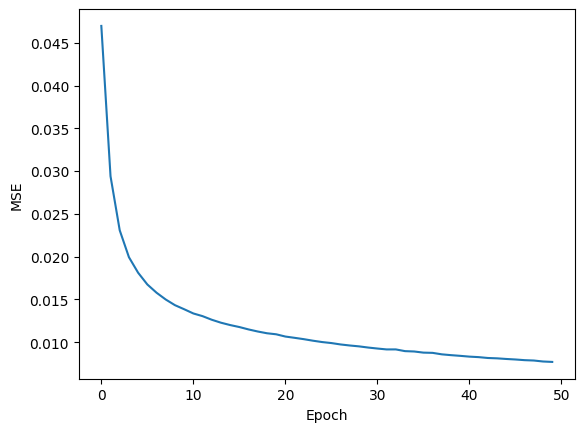

In [94]:
plt.plot(range(len(epoch_loss)), epoch_loss)
plt.ylabel("MSE")
plt.xlabel("Epoch")
plt.show()

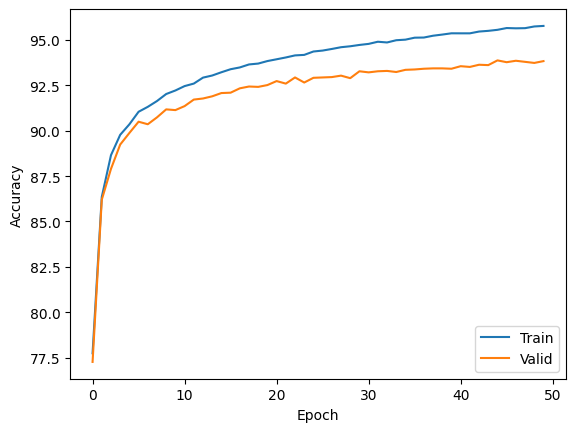

In [97]:
plt.plot(range(len(epoch_train_acc)), epoch_train_acc, label="Train")
plt.plot(range(len(epoch_valid_acc)), epoch_valid_acc, label="Valid")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(loc="lower right")
plt.show()

In [98]:
test_mse, test_acc= compute_mse_and_acc(model, X_test, y_test)
print(f'Точность при тестировании: {test_acc*100:.2f}%')

Точность при тестировании: 94.68%


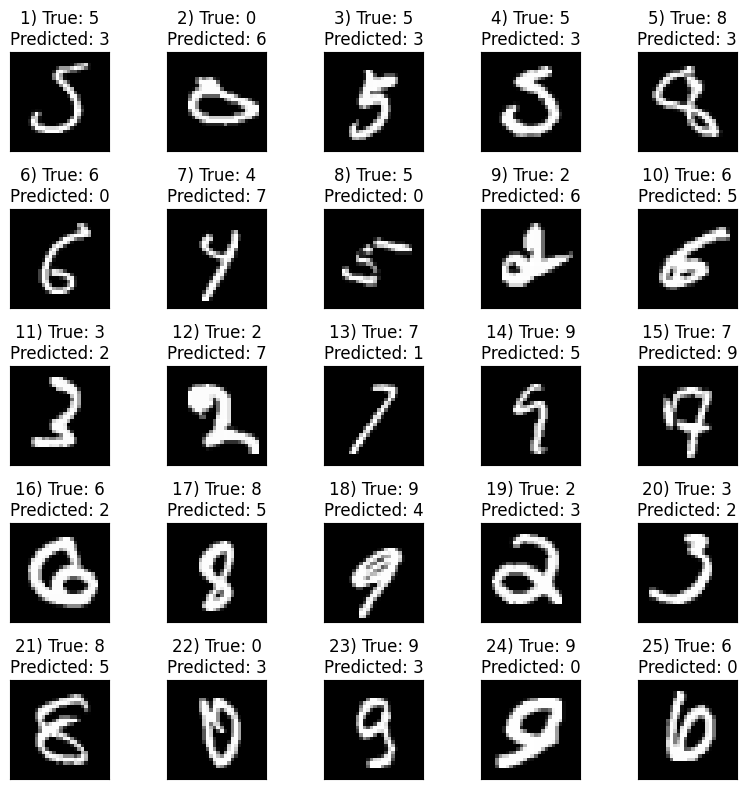

In [101]:
X_test_subset = X_test[:1000, :]
y_test_subset = y_test[:1000]
_, probas = model.forward(X_test_subset)
test_pred = np.argmax(probas, axis=1)
misclassified_images = \
X_test_subset[y_test_subset != test_pred][:25]
misclassified_labels = test_pred[y_test_subset != test_pred][:25]
correct_labels = y_test_subset[y_test_subset != test_pred][:25]
fig, ax = plt.subplots(nrows=5, ncols=5, sharex=True, sharey=True, figsize = (8, 8))
ax = ax.flatten()
for i in range(25):
    img = misclassified_images[i].reshape(28, 28)
    ax[i].imshow(img, cmap=plt.get_cmap('gray'), interpolation='nearest')
    ax[i].set_title(f'{i+1}) '
                    f'True: {correct_labels[i]}\n'
                    f'Predicted: {misclassified_labels[i]}')
ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()